In [1]:

!pip install -q -U "transformers==4.49.0" accelerate peft datasets "pillow<12" bitsandbytes
!pip uninstall -q -y torchao
print("Installation complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 550.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.8 MB/s eta 0:00:00
Installation complete.


In [2]:
import torch
try:
    from transformers import AutoProcessor, AutoModelForImageTextToText as ModelClass
except ImportError:
    from transformers import AutoProcessor, AutoModelForVision2Seq as ModelClass
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_id = "HuggingFaceTB/SmolVLM-256M-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = ModelClass.from_pretrained(model_id, torch_dtype=torch.float16).to(device)


if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "do_image_splitting"):
    processor.image_processor.do_image_splitting = False

print("Model and processor loaded.")

probe = load_dataset("nielsr/docvqa_1200_examples", split="test[:1]")[0]
image = probe["image"]
question = probe["query"]
if isinstance(question, dict):
    question = question.get("en", list(question.values())[0])

messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors="pt").to(device)
generated_ids = model.generate(**inputs, max_new_tokens=50)
output = processor.batch_decode(generated_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print("Question:", question)
print("Model answer:", output[0])

Using device: cuda


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

data/train-00000-of-00001-f795527aa19f0f(…):   0%|          | 0.00/123M [00:00<?, ?B/s]

data/test-00000-of-00001-41a63b2e1b4ecc5(…):   0%|          | 0.00/25.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/200 [00:00<?, ? examples/s]

Question: What the location address of NSDA?
Model answer:  National Soft Drink Association


Train size: 300 | Val size: 60 | Test size: 60

Example 0: Q: What is the subject of the document? | A: Modifications to Eight-Port Sidestream Instrument


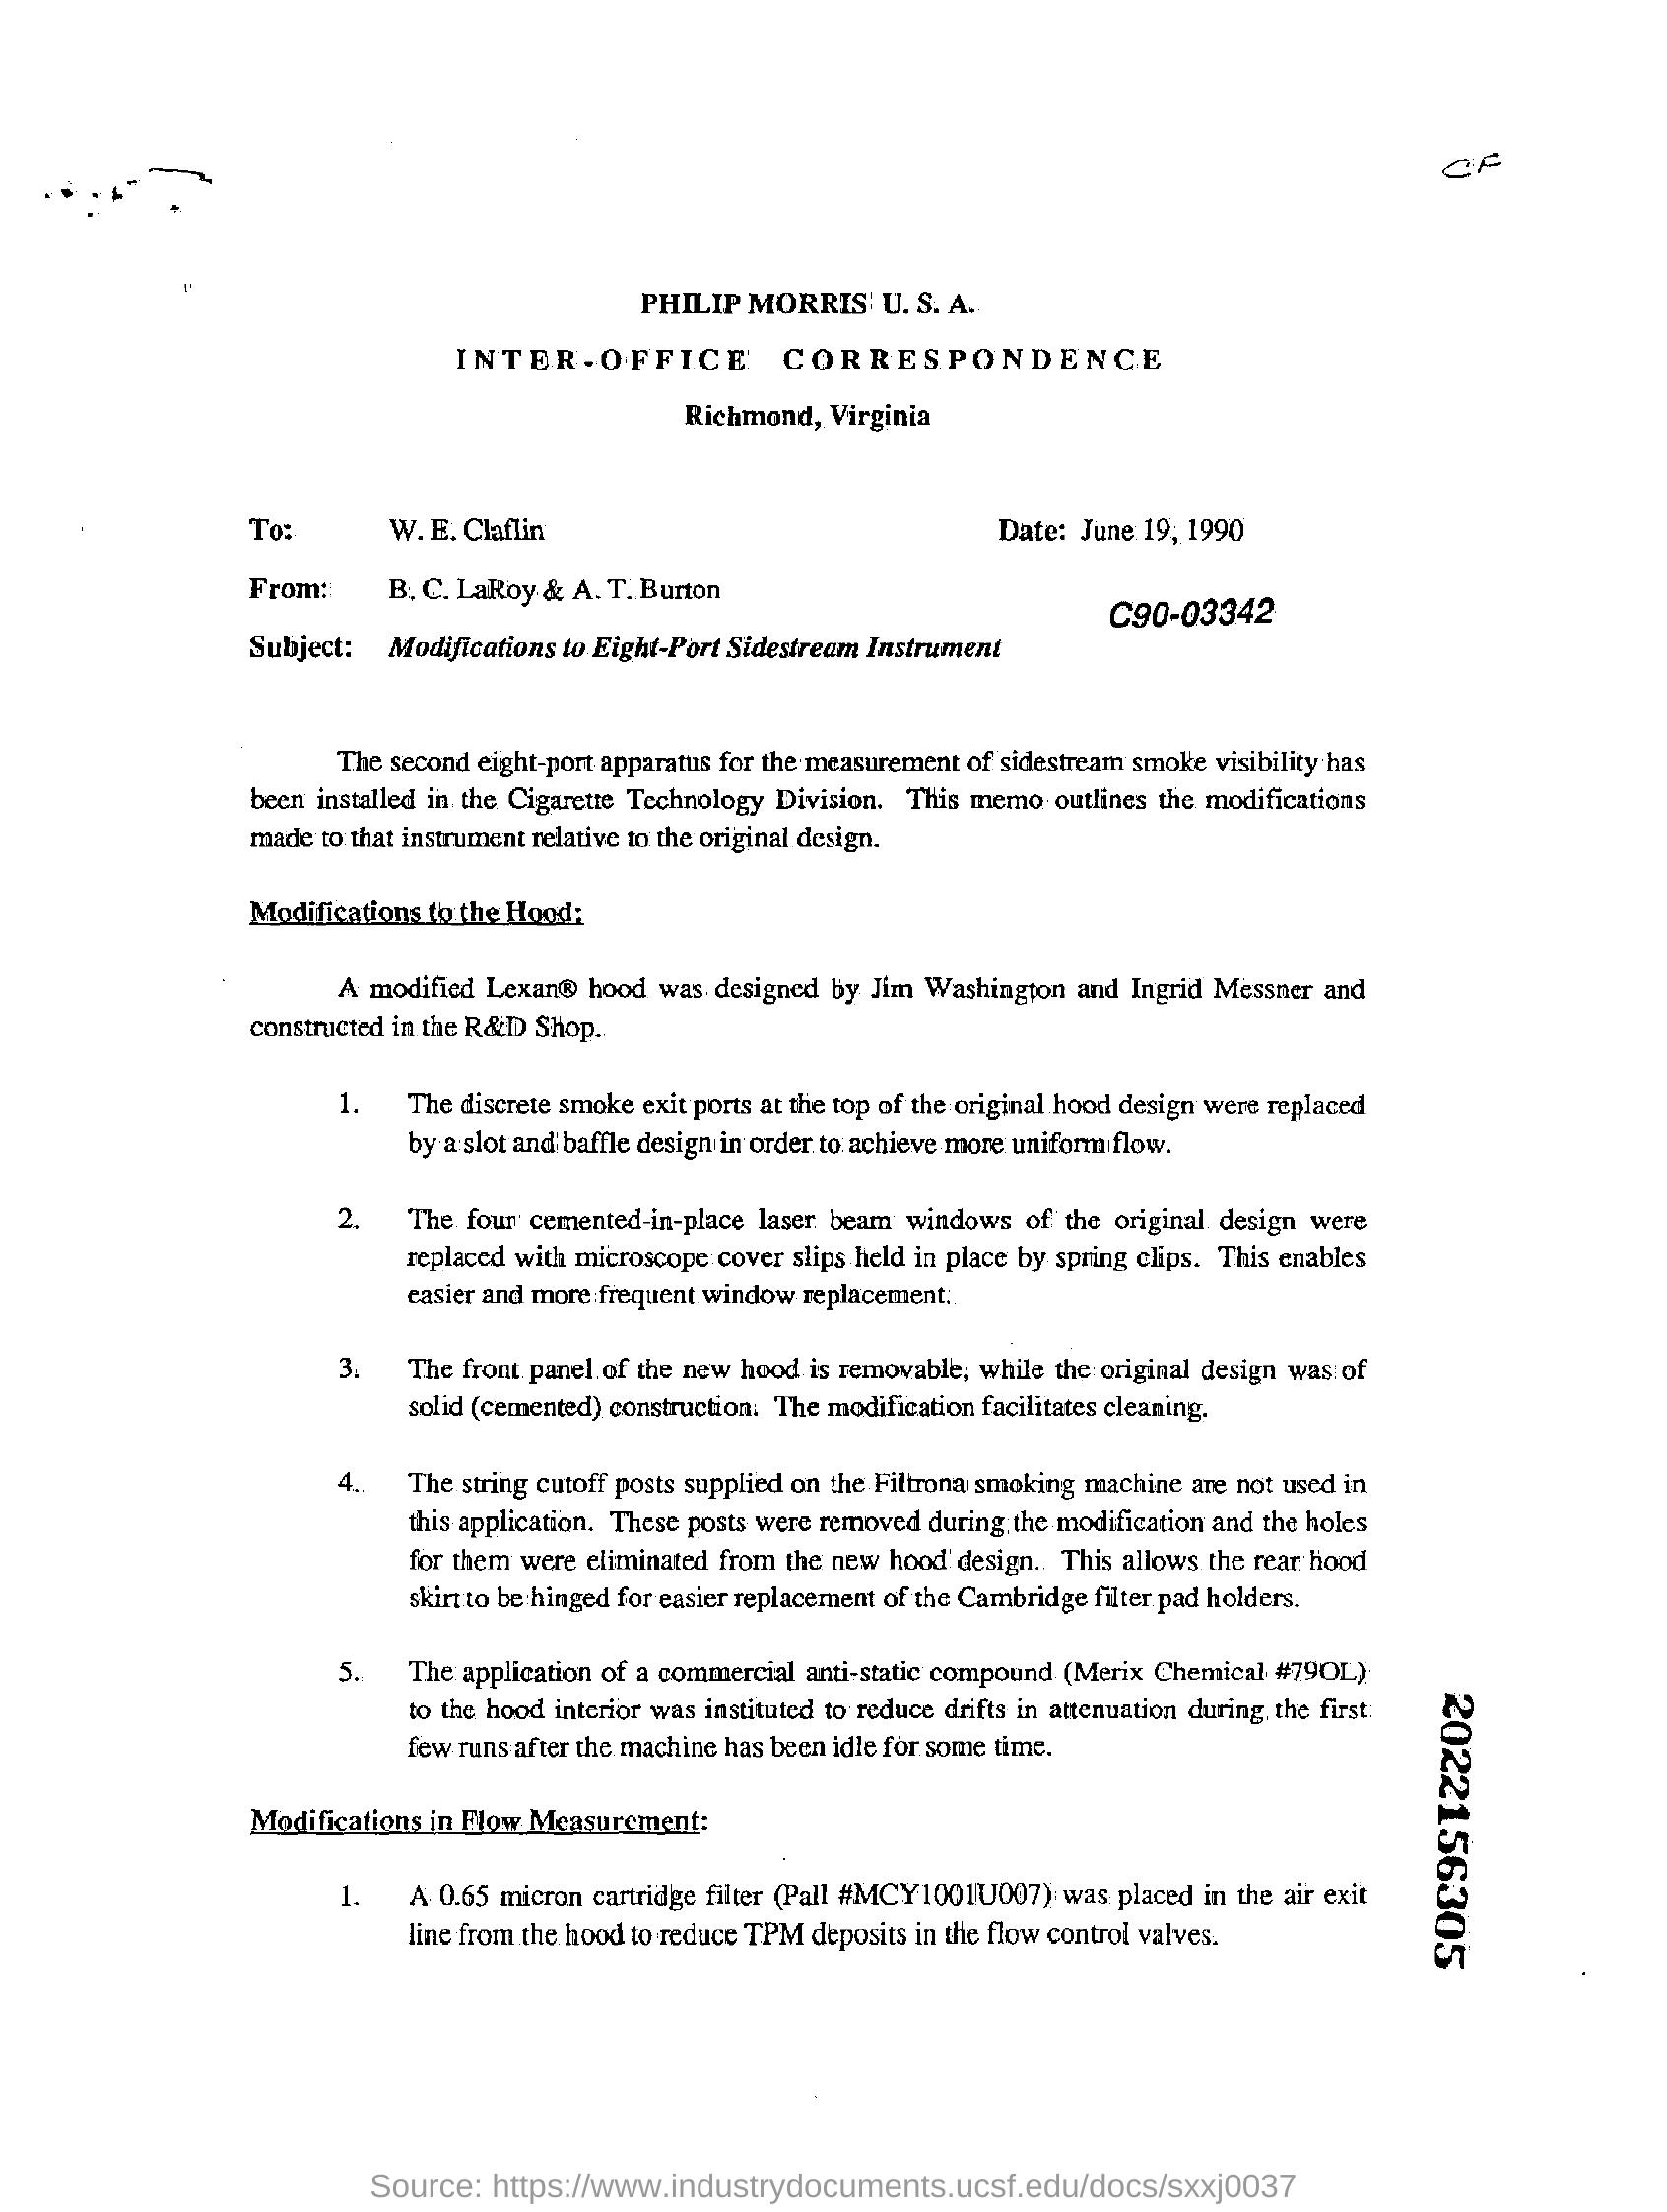


Example 1: Q: Which company's memorandum is given here? | A: GreatWestern United Corporation


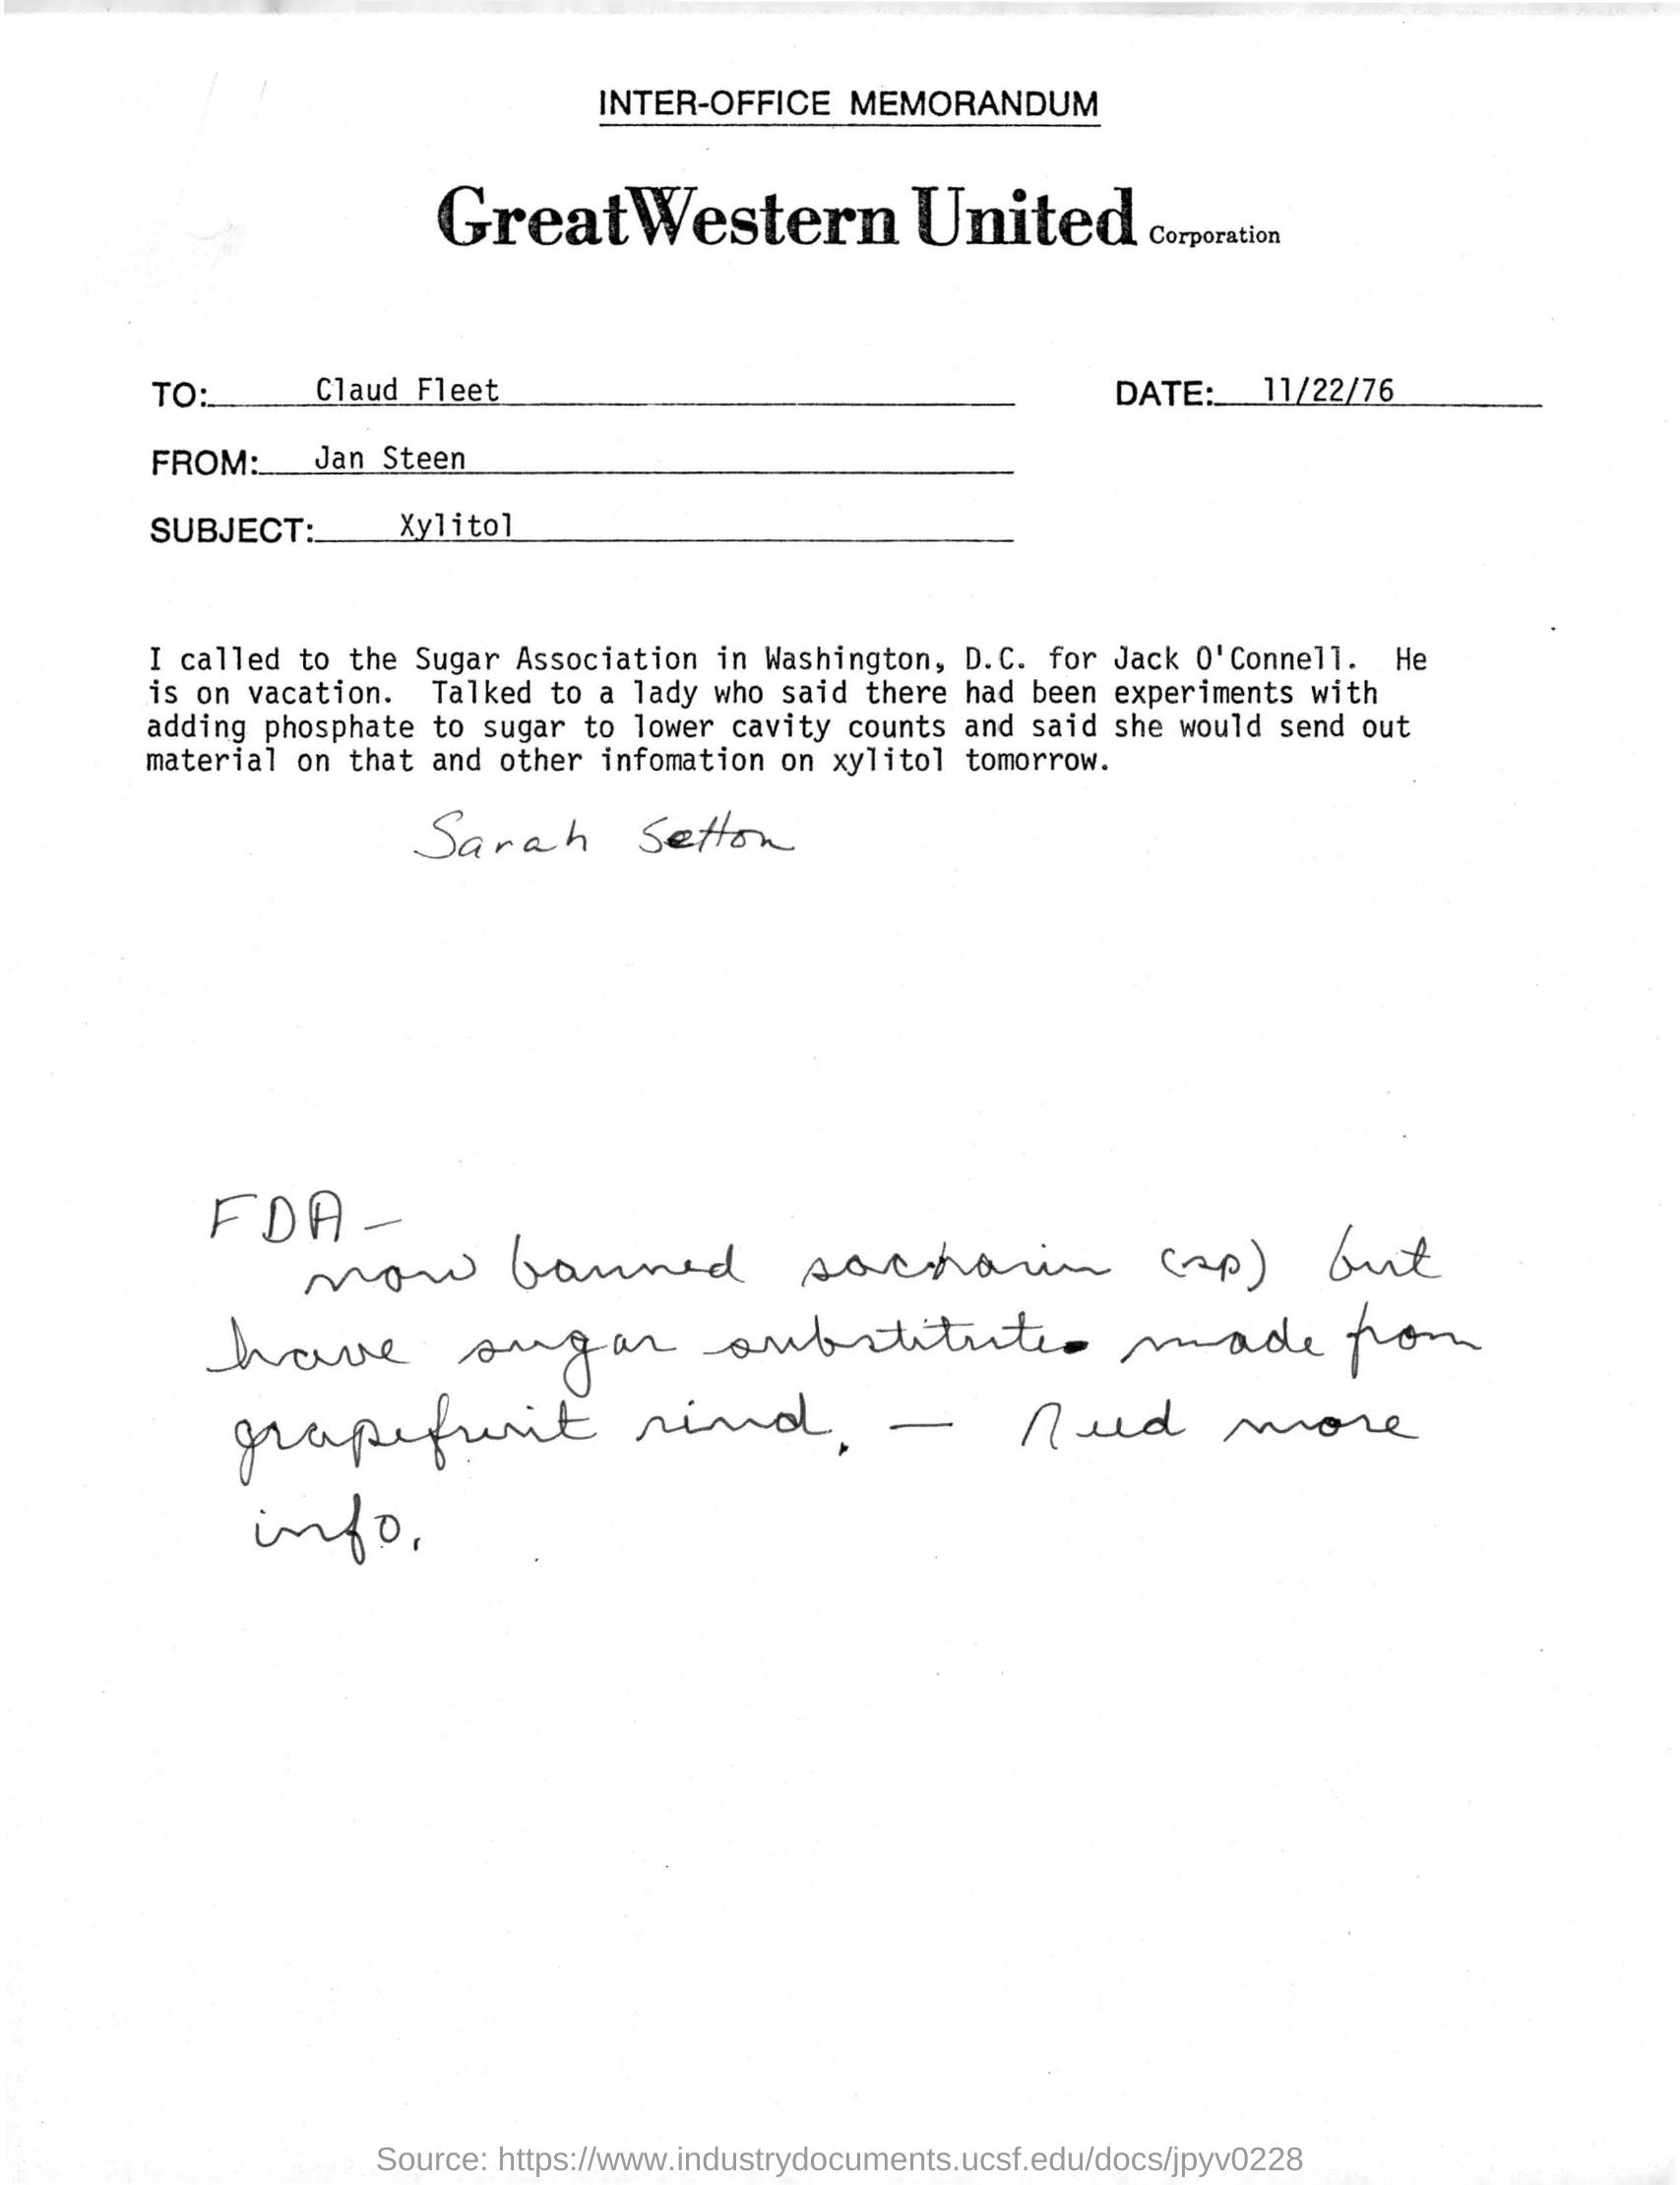

In [3]:

full_ds = load_dataset("nielsr/docvqa_1200_examples", split="test")  # 200 examples in this split
full_ds = full_ds.shuffle(seed=42)

train_ds = full_ds.select(range(0, 300)) if len(full_ds) >= 300 else None

raw_train = load_dataset("nielsr/docvqa_1200_examples", split="train")  # 1000 examples
raw_test = load_dataset("nielsr/docvqa_1200_examples", split="test")    # 200 examples

from datasets import concatenate_datasets
combined = concatenate_datasets([raw_train, raw_test]).shuffle(seed=42)

train_ds = combined.select(range(0, 300))
val_ds = combined.select(range(300, 360))
test_ds = combined.select(range(360, 420))

def get_qa(example):
    q = example.get("query") or example.get("question")
    if isinstance(q, dict):
        q = q.get("en", list(q.values())[0])
    a = example.get("answers")
    if isinstance(a, list):
        a = a[0]
    return q, a

print("Train size:", len(train_ds), "| Val size:", len(val_ds), "| Test size:", len(test_ds))
for i in range(2):
    q, a = get_qa(train_ds[i])
    print(f"\nExample {i}: Q: {q} | A: {a}")
    display(train_ds[i]["image"])

In [4]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,363,968 || all params: 257,848,896 || trainable%: 0.5290


In [5]:
import gc

gc.collect()
torch.cuda.empty_cache()

model.gradient_checkpointing_enable()
model.enable_input_require_grads()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
model.train()

epochs = 2
for epoch in range(epochs):
    for step in range(len(train_ds)):
        example = train_ds[step]
        image = example["image"]
        question, answer = get_qa(example)

        messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}]
        prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
        full_text = prompt + " " + str(answer) + processor.tokenizer.eos_token

        prompt_inputs = processor(text=prompt, images=[image], return_tensors="pt")
        full_inputs = processor(text=full_text, images=[image], return_tensors="pt").to(device)

        prompt_len = prompt_inputs["input_ids"].shape[1]
        labels = full_inputs["input_ids"].clone()
        labels[:, :prompt_len] = -100

        outputs = model(**full_inputs, labels=labels)
        loss = outputs.loss
        loss_val = loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        del outputs, loss, full_inputs, prompt_inputs, labels

        if step % 20 == 0:
            torch.cuda.empty_cache()
            print(f"Epoch {epoch} | Step {step} | Loss: {loss_val:.4f}")

print("Training complete.")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch 0 | Step 0 | Loss: 7.3878
Epoch 0 | Step 20 | Loss: 2.6875
Epoch 0 | Step 40 | Loss: 2.9943
Epoch 0 | Step 60 | Loss: 4.7300
Epoch 0 | Step 80 | Loss: 3.0769
Epoch 0 | Step 100 | Loss: 3.6901
Epoch 0 | Step 120 | Loss: 3.5498
Epoch 0 | Step 140 | Loss: 1.2018
Epoch 0 | Step 160 | Loss: 1.1345
Epoch 0 | Step 180 | Loss: 2.6044
Epoch 0 | Step 200 | Loss: 4.9052
Epoch 0 | Step 220 | Loss: 4.1776
Epoch 0 | Step 240 | Loss: 1.4525
Epoch 0 | Step 260 | Loss: 4.9040
Epoch 0 | Step 280 | Loss: 4.8998
Epoch 1 | Step 0 | Loss: 5.5685
Epoch 1 | Step 20 | Loss: 2.2458
Epoch 1 | Step 40 | Loss: 2.2459
Epoch 1 | Step 60 | Loss: 3.2703
Epoch 1 | Step 80 | Loss: 2.5973
Epoch 1 | Step 100 | Loss: 2.6602
Epoch 1 | Step 120 | Loss: 3.3743
Epoch 1 | Step 140 | Loss: 1.1982
Epoch 1 | Step 160 | Loss: 0.5031
Epoch 1 | Step 180 | Loss: 2.4625
Epoch 1 | Step 200 | Loss: 4.9321
Epoch 1 | Step 220 | Loss: 3.3196
Epoch 1 | Step 240 | Loss: 0.8597
Epoch 1 | Step 260 | Loss: 4.8388
Epoch 1 | Step 280 | Loss:

In [6]:
model.save_pretrained("/kaggle/working/smolvlm-lora-adapter-v2")
processor.save_pretrained("/kaggle/working/smolvlm-lora-adapter-v2")
print("Adapter saved to /kaggle/working/smolvlm-lora-adapter-v2")

Adapter saved to /kaggle/working/smolvlm-lora-adapter-v2


In [7]:
import re
def normalize(text):
    return re.sub(r"[^a-z0-9.]", "", str(text).lower())

def is_close_match(answer, pred):
    a, p = normalize(answer), normalize(pred)
    if a in p or p in a:
        return True
    try:
        a_num = float(re.sub(r"[^0-9.]", "", a))
        p_num = float(re.sub(r"[^0-9.]", "", p))
        if a_num == 0:
            return False
        return abs(a_num - p_num) / a_num < 0.15
    except ValueError:
        return False

def run_inference(model, image, question):
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=prompt, images=[image], return_tensors="pt").to(device)
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=30)
    output = processor.batch_decode(generated_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    del inputs, generated_ids
    return output[0]

def evaluate(model, dataset, image_transform=None):
    model.eval()
    correct = 0
    for example in dataset:
        image = example["image"]
        if image_transform:
            image = image_transform(image)
        question, answer = get_qa(example)
        pred = run_inference(model, image, question)
        if is_close_match(answer, pred):
            correct += 1
    return correct / len(dataset)

try:
    del optimizer
except NameError:
    pass
model.eval()
for p in model.parameters():
    p.grad = None
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed. Free/total:", torch.cuda.mem_get_info())

base_model = ModelClass.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
base_val_acc = evaluate(base_model, val_ds)

del base_model
gc.collect()
torch.cuda.empty_cache()

finetuned_val_acc = evaluate(model, val_ds)

print("Base (val):", base_val_acc, "| Fine-tuned (val):", finetuned_val_acc)

GPU memory freed. Free/total: (14886436864, 15636037632)
Base (val): 0.3 | Fine-tuned (val): 0.3


In [8]:
from PIL import ImageFilter
import random
import io

random.seed(42)

_target_size = processor.image_processor.size
if isinstance(_target_size, dict):
    _side = _target_size.get("longest_edge") or _target_size.get("shortest_edge") or 384
    _target_size = (_side, _side)
print("Applying corruptions at model input resolution:", _target_size)

def _prep(image):
    return image.resize(_target_size)

def blur_image(image):
    return _prep(image).filter(ImageFilter.GaussianBlur(radius=2))

def rotate_image(image):
    angle = random.choice([-10, 10])
    return _prep(image).rotate(angle, expand=False, fillcolor="white")

print("Corruption functions ready (corrected for resize-order bug).")

Applying corruptions at model input resolution: (2048, 2048)
Corruption functions ready (corrected for resize-order bug).


In [9]:
blur_val_acc = evaluate(model, val_ds, image_transform=blur_image)
rotate_val_acc = evaluate(model, val_ds, image_transform=rotate_image)

print("Fine-tuned (val, blur):", blur_val_acc)
print("Fine-tuned (val, rotation):", rotate_val_acc)

Fine-tuned (val, blur): 0.38333333333333336
Fine-tuned (val, rotation): 0.25


In [10]:

base_model = ModelClass.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
base_test_acc = evaluate(base_model, test_ds)
del base_model
gc.collect()
torch.cuda.empty_cache()

finetuned_test_acc = evaluate(model, test_ds)
blur_test_acc = evaluate(model, test_ds, image_transform=blur_image)
rotate_test_acc = evaluate(model, test_ds, image_transform=rotate_image)

results = {
    "Base (test, clean)": base_test_acc,
    "Fine-tuned (test, clean)": finetuned_test_acc,
    "Fine-tuned (test, blur)": blur_test_acc,
    "Fine-tuned (test, rotation)": rotate_test_acc,
}
print(results)

{'Base (test, clean)': 0.18333333333333332, 'Fine-tuned (test, clean)': 0.26666666666666666, 'Fine-tuned (test, blur)': 0.45, 'Fine-tuned (test, rotation)': 0.13333333333333333}


                  Condition  Accuracy
         Base (test, clean)  0.183333
   Fine-tuned (test, clean)  0.266667
    Fine-tuned (test, blur)  0.450000
Fine-tuned (test, rotation)  0.133333


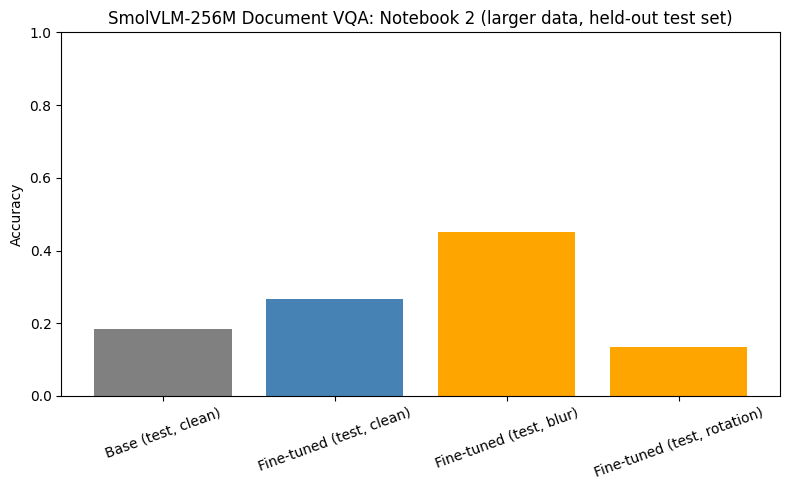

Saved results_table_v2.csv and results_chart_v2.png to /kaggle/working/


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(list(results.items()), columns=["Condition", "Accuracy"])
print(df.to_string(index=False))
df.to_csv("/kaggle/working/results_table_v2.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(df["Condition"], df["Accuracy"], color=["gray", "steelblue", "orange", "orange"])
plt.ylabel("Accuracy")
plt.title("SmolVLM-256M Document VQA: Notebook 2 (larger data, held-out test set)")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("/kaggle/working/results_chart_v2.png")
plt.show()
print("Saved results_table_v2.csv and results_chart_v2.png to /kaggle/working/")

In [12]:
print("=== CLEAN vs BLUR prediction comparison (test set, first 15) ===\n")
clean_lengths = []
blur_lengths = []

for i in range(15):
    example = test_ds[i]
    question, answer = get_qa(example)

    clean_pred = run_inference(model, example["image"], question)
    blur_pred = run_inference(model, blur_image(example["image"]), question)

    clean_lengths.append(len(clean_pred.strip()))
    blur_lengths.append(len(blur_pred.strip()))

    print(f"Q: {question}")
    print(f"  Ground truth: {answer}")
    print(f"  Clean pred : '{clean_pred.strip()}'  (len={len(clean_pred.strip())})")
    print(f"  Blur pred  : '{blur_pred.strip()}'  (len={len(blur_pred.strip())})")
    print()

import statistics
print("Avg clean prediction length:", statistics.mean(clean_lengths))
print("Avg blur prediction length:", statistics.mean(blur_lengths))

=== CLEAN vs BLUR prediction comparison (test set, first 15) ===

Q: How much percent of consumers reads labels?
  Ground truth: 20%
  Clean pred : '10%'  (len=3)
  Blur pred  : '20'  (len=2)

Q: By whom  a great deal of advertising is produced locally?
  Ground truth: bottlers,
  Clean pred : 'Mr. Michael F. Jacobson'  (len=23)
  Blur pred  : 'Bottles'  (len=7)

Q: What is the heading of the document?
  Ground truth: TPNA/TEUR&D/TCI ACTOS RESPONSE MEETING
  Clean pred : 'TPA/Eurotur/ACTOS Response Meeting'  (len=34)
  Blur pred  : 'TP&E/TURF/ACTOS Response Meeting'  (len=32)

Q: who were treated to a sweetened chocolate drink by aztec emporer montezuma?
  Ground truth: spanish conquerors
  Clean pred : 'Caffeine'  (len=8)
  Blur pred  : 'Caffeine'  (len=8)

Q: Which company is mentioned in the letterhead?
  Ground truth: THE UPJOHN COMPANY
  Clean pred : 'THE UPJOHN COMPANY'  (len=18)
  Blur pred  : 'THE UPHOJIN COMPANY'  (len=19)

Q: Which brand does the sub brand 'fresh' belong to?


In [13]:
def exact_match(answer, pred):
    return normalize(answer) == normalize(pred)

def evaluate_dual(model, dataset, image_transform=None):
    model.eval()
    exact_correct = 0
    fuzzy_correct = 0
    for example in dataset:
        image = example["image"]
        if image_transform:
            image = image_transform(image)
        question, answer = get_qa(example)
        pred = run_inference(model, image, question)
        if exact_match(answer, pred):
            exact_correct += 1
        if is_close_match(answer, pred):
            fuzzy_correct += 1
    n = len(dataset)
    return exact_correct / n, fuzzy_correct / n

base_model = ModelClass.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
base_exact, base_fuzzy = evaluate_dual(base_model, test_ds)
del base_model
gc.collect()
torch.cuda.empty_cache()

ft_exact, ft_fuzzy = evaluate_dual(model, test_ds)
blur_exact, blur_fuzzy = evaluate_dual(model, test_ds, image_transform=blur_image)
rotate_exact, rotate_fuzzy = evaluate_dual(model, test_ds, image_transform=rotate_image)

results_dual = {
    "Base (clean)": (base_exact, base_fuzzy),
    "Fine-tuned (clean)": (ft_exact, ft_fuzzy),
    "Fine-tuned (blur)": (blur_exact, blur_fuzzy),
    "Fine-tuned (rotation)": (rotate_exact, rotate_fuzzy),
}
for k, (e, f) in results_dual.items():
    print(f"{k}: exact={e:.3f}, fuzzy={f:.3f}")

Base (clean): exact=0.117, fuzzy=0.183
Fine-tuned (clean): exact=0.183, fuzzy=0.267
Fine-tuned (blur): exact=0.283, fuzzy=0.450
Fine-tuned (rotation): exact=0.067, fuzzy=0.200
